<img style="float: center;" src='https://github.com/spacetelescope/jwst-pipeline-notebooks/raw/main/_static/stsci_header.png' alt="stsci_logo" width="900px"/> 

# Extracting FS Data from MOS/IFU Observations

**Authors**: Kayli Glidic (kglidic@stsci.edu), with contributions from Chris Hayes; NIRSpec branch<br>
**Last Updated**: April 30, 2026 </br>

**Purpose**:<br>
The primary goal of this notebook is to demonstrate how to extract fixed slit (FS) data from multi-object spectroscopy (MOS) and integral field unit (IFU) NIRSpec observations.

**[Data](#4.-Download-the-Data)**:<br>
This notebook is set up to use PRISM MOS and IFU observations in which the fixed slits (FS) were generally observing background. The data were obtained from Proposal IDs (PIDs) 2750 (MOS) and 1216 (IFU).


---

## Table of Contents
* [1. Introduction](#1.-Introduction)
* [2. Package Imports](#2.-Package-Imports)
* [3. Download the Data](#4.-Download-the-Data)
* [4. Prepare to Extract FS Data from MOS Observations](#5.-Prepare-to-Extract-FS-Data-from-MOS-Observations)
* [5. Prepare to Extract FS Data from IFU Observations](#6.-Prepare-to-Extract-FS-Data-from-IFU-Observations)
* [6. Extract FS Data from MOS/IFU Observations (Stage 2)](#7.-Extract-FS-Data-from-MOS/IFU-Observations-(Stage-2))
* [7. Extract FS Data from MOS/IFU Observations (Stage 3)](#8.-Extract-FS-Data-from-MOS/IFU-Observations-(Stage-3))





---

## 1. Introduction

The Near Infrared Spectrograph (NIRSpec) includes several [FS apertures](https://jwst-docs.stsci.edu/jwst-near-infrared-spectrograph/nirspec-instrumentation/nirspec-fixed-slits#gsc.tab=0:~:text=NIRSpec%20Fixed%20Slits-,NIRSpec%20Fixed%20Slits,-The%C2%A0NIRSpec) machined directly into the mounting plate of the micro-shutter assembly (MSA). 

The available NIRSpec FS's are:
* S200A1
* S200A2
* S200B1 (redundant with S200A1; not used for science)
* S400A1
* S1600A1

These slits remain open during all observations, including MOS and IFU modes. Because these FS spectra fall on a different detector region than MOS or IFU spectra, they are unaffected by failed open MSA shutters. As a result, the FS's can be used as additional background observations (if no source contamination) or have other sources of potential interest fall within them. 

Currently, however, FS data are not automatically processed from MOS or IFU observations, except when planned in APT using the FS + MOS template, which allows FS targets to be explicitly planned and processed.

This notebook provides a workaround for extracting and processing FS data from these types of observations.



---

## 2. Package Imports

In [1]:
# General imports.
import os
import glob
from collections import defaultdict

# Astropy imports.
from astropy.table import Table
from astropy.io import fits

# set CRDS environment variables
os.environ['CRDS_PATH'] = os.environ['HOME']+'/crds_cache'
os.environ['CRDS_SERVER_URL'] = 'https://jwst-crds.stsci.edu'

# JWST pipeline imports.
from jwst.pipeline import Spec2Pipeline  # calwebb_spec2
from jwst.pipeline import Spec3Pipeline  # calwebb_spec3

# import our own custom helper functions from the utils file in this directory
# these functions handle tasks including downloading data products from MAST, adding
# FS targets to MSA metadata files, creating Stage 3 association files, and plotting NIRSpec spectra
from utils import download_jwst_files, add_fs_target, writel3asn, display_spectra


---

## 3. Download the Data

Below, we will download example MOS and IFU data, along with the corresponding MSA metadata file for the MOS observation. Users can also set optionally set `demo` to `False` provide other rate data.

In [2]:
# Define data directory.
data_dir = 'data/'
stage2_dir = os.path.join(data_dir, 'stage2/')
stage3_dir = os.path.join(data_dir, 'stage3/')

os.makedirs(data_dir, exist_ok=True)
os.makedirs(stage2_dir, exist_ok=True)
os.makedirs(stage3_dir, exist_ok=True)

In [3]:
demo = True
if demo == True:
    # Download the demo example MOS and IFU rate files.
    mos_rates = [f'jw02750002001_07101_{i:05d}_nrs1_rate.fits' for i in range(1, 4)]  # 3 NODS
    ifu_rates = [f'jw01216005001_03103_{i:05d}_nrs1_rate.fits' for i in range(1, 9)]  # 8 DITHERS
    mos_rates = download_jwst_files(mos_rates, data_dir)
    ifu_rates = download_jwst_files(ifu_rates, data_dir)
else:
    # Provide list of paths to other rate files.
    mos_rates = []
    ifu_rate = []

 [Done]


 [Done]


 [Done]


 [Done]


 [Done]


...

 [Done]


 [Done]


 [Done]


 [Done]


 [Done]


In [4]:
# Get the MSA metadata file name from one of the rate headers and download.
msa_metafile_name = fits.getval(mos_rates[0], 'MSAMETFL')
msa_metafile = download_jwst_files([msa_metafile_name], data_dir)[0]
msa_metafile

 [Done]


'data/jw02750002001_01_msa.fits'

---

## 4. Prepare to Extract FS Data from MOS Observations

The NIRSpec MSA metadata file is a crucial component of the calibration processing for MOS exposures. It contains all the slitlet, shutter, and source configuration information required by the `calwebb_spec2` pipeline to process a MOS observation accurately. For more information on the contents of these MSA metafiles, refer to this example [notebook](https://github.com/spacetelescope/jdat_notebooks/blob/main/notebooks/NIRSpec/msa_metafile/NIRSpec_MOS_MSA_metafile.ipynb).

To process FS data from a MOS observation, the FS targets must also be included in the metadata file. In this section, we demonstrate how to edit a metadata file to include each of the FSs.

For this example we are extracting background. So, we assume that the target is centered in each slit, the sources are extended (stellarity = 0), and they are defined as the `primary_source` in the metadata file so that they are properly processed. 


<div class="alert alert-block alert-warning">

For point sources, the `pathloss` and `wavecorr` steps depend on accurate source positioning. Users should carefully inspect their data to ensure the source location is correct when performing FS extraction.

</div>

In [5]:
# Load MSA metafile and its source and shutter tables.
msa_hdu_list = fits.open(msa_metafile)
source_table = Table(msa_hdu_list['SOURCE_INFO'].data)
shutter_table = Table(msa_hdu_list['SHUTTER_INFO'].data)

In [6]:
# Source coordinates and stellarity.
ra = 0.0
dec = 0.0
stellarity = 0.0  # point source = 1.0, extended source = 0.0

# Add each FS to the metadata file.
for slit_name in ['S200A1', 'S200A2', 'S400A1', 'S1600A1']:
    new_slit_id, new_source_id, shutter_table, source_table = add_fs_target(
        shutter_table,
        source_table,
        mos_rates[0],  # Use one of the rate files for general header information.
        slit_name,
        ra, dec,
        stellarity=stellarity
    )

msa_hdu_list['SHUTTER_INFO'] = fits.table_to_hdu(shutter_table)
msa_hdu_list['SOURCE_INFO'] = fits.table_to_hdu(source_table)

msa_hdu_list[2].name = 'SHUTTER_INFO'
msa_hdu_list[3].name = 'SOURCE_INFO'

msa_hdu_list.writeto(msa_metafile, overwrite=True)
msa_hdu_list.close()

In [7]:
# Load the MSA metafile and inspect additions.
msa_hdu_list = fits.open(msa_metafile)
source_table = Table(msa_hdu_list['SOURCE_INFO'].data)
shutter_table = Table(msa_hdu_list['SHUTTER_INFO'].data)
shutter_table

slitlet_id,msa_metadata_id,shutter_quadrant,shutter_row,shutter_column,source_id,background,shutter_state,estimated_source_in_shutter_x,estimated_source_in_shutter_y,dither_point_index,primary_source,fixed_slit
int16,int16,int16,int16,int16,int32,str1,str6,float32,float32,int16,str1,str7
2,1,1,10,116,0,Y,OPEN,nan,nan,1,N,NONE
2,1,1,10,116,0,Y,OPEN,nan,nan,2,N,NONE
2,1,1,10,116,0,Y,OPEN,nan,nan,3,N,NONE
2,1,1,10,117,0,Y,OPEN,nan,nan,1,N,NONE
2,1,1,10,117,0,Y,OPEN,nan,nan,2,N,NONE
2,1,1,10,117,0,Y,OPEN,nan,nan,3,N,NONE
2,1,1,10,118,0,Y,OPEN,nan,nan,1,N,NONE
2,1,1,10,118,0,Y,OPEN,nan,nan,2,N,NONE
2,1,1,10,118,0,Y,OPEN,nan,nan,3,N,NONE


---

## 5. Prepare to Extract FS Data from IFU Observations

Unlike MOS observations, IFU observations do not require an MSA metadata file for processing spectra through `calwebb_spec2`. In fact, even the MOS observations do not require a metafile if the goal is simply to extract FS data. To enable FS extraction from IFU or MOS observations, the `EXP_TYPE` keyword in the rate file header must be set to `NRS_FIXEDSLIT`, which triggers the pipeline to perform FS spectral extraction. By default, the pipeline treats all FS’s as extended sources and extracts a spectrum from the center of each slit. This is ideal for getting additional background observations. **However, if attempting to process a point source, there are several important considerations**.

* To process a point source, a primary slit must be defined using the `FXD_SLIT` header keyword, and the source type must be set to point (`SRCTYAPT` = `POINT`); otherwise, the pipeline will continue to treat the source as extended. In addition, for the `wavecorr` step to run properly on the selected slit, the correct slit-dependent reference values (`V2_REF`, `V3_REF`, and `V3I_YANG`) must be provided. If these are not updated, the pipeline will retain the original IFU values and may skip this step with a warning about non-invertible corrections.

* The `XOFFSET` and `YOFFSET` values in IFU data are based on their respective dither/nod patterns and do not nessesarily correspond to FS dither/nod positions. As a result, the source may fall within the slit for some exposures but not others. Because the pipeline uses these offsets to estimate the source location, it can incorrectly place the source outside the FS, leading to steps like pathloss being skipped or applied incorrectly and the `extract_1d` step to perform poorly.


In [8]:
# Choose a primary FS to process (optional).
FXD_SLIT = None  # 'S200A1' or S200A2 or S400A1 or S1600A1

for ifu_rate in ifu_rates:
    with fits.open(ifu_rate, 'update') as hdul:

        hdul[0].header['EXP_TYPE'] = 'NRS_FIXEDSLIT'
        #hdul[0].header['SRCTYAPT'] = 'POINT'  # To process primary source as a point source.
        
        if FXD_SLIT == 'S200A1':

            hdul[0].header['FXD_SLIT'] = FXD_SLIT  # Set the primary slit.
            #hdul[0].header['XOFFSET'] = 0.0  # Set for point source but with caution.
            #hdul[0].header['YOFFSET'] = 0.0  # Set for point source but with caution.

            # Reference postions for S200A1 FS observations.
            hdul[1].header['V2_REF'] = 331.867035  # [arcsec] Telescope V2 coord of reference point
            hdul[1].header['V3_REF'] = -479.417542  # [arcsec] Telescope V3 coord of reference point 
            hdul[1].header['VPARITY'] = -1  # Relative sense of rotation between Ideal xy and
            hdul[1].header['V3I_YANG'] = 138.84190369  # [deg] Angle from V3 axis to Ideal y axis

        elif FXD_SLIT == 'S200A2':

            hdul[0].header['FXD_SLIT'] = FXD_SLIT 
            #hdul[0].header['XOFFSET'] = 0.0 
            #hdul[0].header['YOFFSET'] = 0.0

            # Reference postions for S200A2 FS observations.
            hdul[1].header['V2_REF'] = 314.697998
            hdul[1].header['V3_REF'] = -489.614227 
            hdul[1].header['VPARITY'] = -1
            hdul[1].header['V3I_YANG'] = 138.91368103

        elif FXD_SLIT == 'S400A1':

            hdul[0].header['FXD_SLIT'] = FXD_SLIT 
            #hdul[0].header['XOFFSET'] = 0.0 
            #hdul[0].header['YOFFSET'] = 0.0

            # Reference postions for S400A1 FS observations.
            hdul[1].header['V2_REF'] = 321.59079
            hdul[1].header['V3_REF'] = -478.107422
            hdul[1].header['VPARITY'] = -1
            hdul[1].header['V3I_YANG'] = 138.864151

        elif FXD_SLIT == 'S1600A1':

            hdul[0].header['FXD_SLIT'] = FXD_SLIT 
            #hdul[0].header['XOFFSET'] = 0.0 
            #hdul[0].header['YOFFSET'] = 0.0

            # Reference postions for S1600A1 FS observations.
            hdul[1].header['V2_REF'] = 321.26297
            hdul[1].header['V3_REF'] = -473.851288
            hdul[1].header['VPARITY'] = -1
            hdul[1].header['V3I_YANG'] = 138.85295105

---

## 6. Extract FS Data from MOS/IFU Observations (Stage 2)

Run Stage 2 and extract the spectra. Note we are not providing Stage 2 association files here.

In [9]:
# Select a FS's source to extract and inspect.
slit_names = ['S200A1', 'S200A2', 'S400A1', 'S1600A1']

In [10]:
# Set up a dictionary to define how the Spec2 pipeline should be configured.

spec2dict = defaultdict(dict)
 
# Extract specific sources; saves on processing time.
if slit_names is not None:
    spec2dict['extract_2d']['slit_names'] = slit_names

# We assume the source is centered in the slit.
spec2dict['extract_1d']['use_source_posn'] = True


In [11]:
# Run Stage 2 pipeline using the custom spec2dict dictionary.

for file in mos_rates + ifu_rates:
    print(f"Applying Stage 2 Corrections & Calibrations to: {file}")
    spec2sci_result = Spec2Pipeline.call(file,
                                        save_results=True,
                                        steps=spec2dict,
                                        output_dir=stage2_dir)
            
    print("Stage 2 has been completed! \n")


Applying Stage 2 Corrections & Calibrations to: data/jw02750002001_07101_00001_nrs1_rate.fits


2026-05-12 21:02:11,126 - CRDS - INFO -  Calibration SW Found: jwst 2.0.1 (/home/runner/micromamba/envs/ci-env/lib/python3.11/site-packages/jwst-2.0.1.dist-info)


2026-05-12 21:02:11,993 - CRDS - INFO -  Fetching  /home/runner/crds_cache/mappings/jwst/jwst_system_datalvl_0002.rmap      694 bytes  (1 / 224 files) (0 / 796.2 K bytes)


2026-05-12 21:02:12,052 - CRDS - INFO -  Fetching  /home/runner/crds_cache/mappings/jwst/jwst_system_calver_0069.rmap    5.8 K bytes  (2 / 224 files) (694 / 796.2 K bytes)


2026-05-12 21:02:12,194 - CRDS - INFO -  Fetching  /home/runner/crds_cache/mappings/jwst/jwst_system_0064.imap      385 bytes  (3 / 224 files) (6.5 K / 796.2 K bytes)


...

2026-05-12 21:06:53,009 - jwst.stpipe.core - INFO - Results used CRDS context: jwst_1535.pmap


2026-05-12 21:06:53,488 - stpipe.step - INFO - Saved model in data/stage2/jw01216005001_03103_00008_nrs1_cal.fits


2026-05-12 21:06:53,489 - stpipe.step - INFO - Step Spec2Pipeline done


2026-05-12 21:06:53,489 - jwst.stpipe.core - INFO - Results used jwst version: 2.0.1


Stage 2 has been completed! 



In [12]:
# List the Stage 2 products.

# -----------------------------Science files-----------------------------
sci_cal = sorted(glob.glob(stage2_dir + '*_cal.fits'))
sci_s2d = sorted(glob.glob(stage2_dir + '*_s2d.fits'))
sci_x1d = sorted(glob.glob(stage2_dir + '*_x1d.fits'))

print(f"SCIENCE | Stage 2 CAL Products:\n{'-' * 20}\n" + "\n".join(sci_cal))
print(f"SCIENCE | Stage 2 S2D Products:\n{'-' * 20}\n" + "\n".join(sci_s2d))
print(f"SCIENCE | Stage 2 X1D Products:\n{'-' * 20}\n" + "\n".join(sci_x1d))

SCIENCE | Stage 2 CAL Products:
--------------------
data/stage2/jw01216005001_03103_00001_nrs1_cal.fits
data/stage2/jw01216005001_03103_00002_nrs1_cal.fits
data/stage2/jw01216005001_03103_00003_nrs1_cal.fits
data/stage2/jw01216005001_03103_00004_nrs1_cal.fits
data/stage2/jw01216005001_03103_00005_nrs1_cal.fits
data/stage2/jw01216005001_03103_00006_nrs1_cal.fits
data/stage2/jw01216005001_03103_00007_nrs1_cal.fits
data/stage2/jw01216005001_03103_00008_nrs1_cal.fits
data/stage2/jw02750002001_07101_00001_nrs1_cal.fits
data/stage2/jw02750002001_07101_00002_nrs1_cal.fits
data/stage2/jw02750002001_07101_00003_nrs1_cal.fits
SCIENCE | Stage 2 S2D Products:
--------------------
data/stage2/jw01216005001_03103_00001_nrs1_s2d.fits
data/stage2/jw01216005001_03103_00002_nrs1_s2d.fits
data/stage2/jw01216005001_03103_00003_nrs1_s2d.fits
data/stage2/jw01216005001_03103_00004_nrs1_s2d.fits
data/stage2/jw01216005001_03103_00005_nrs1_s2d.fits
data/stage2/jw01216005001_03103_00006_nrs1_s2d.fits
data/stage

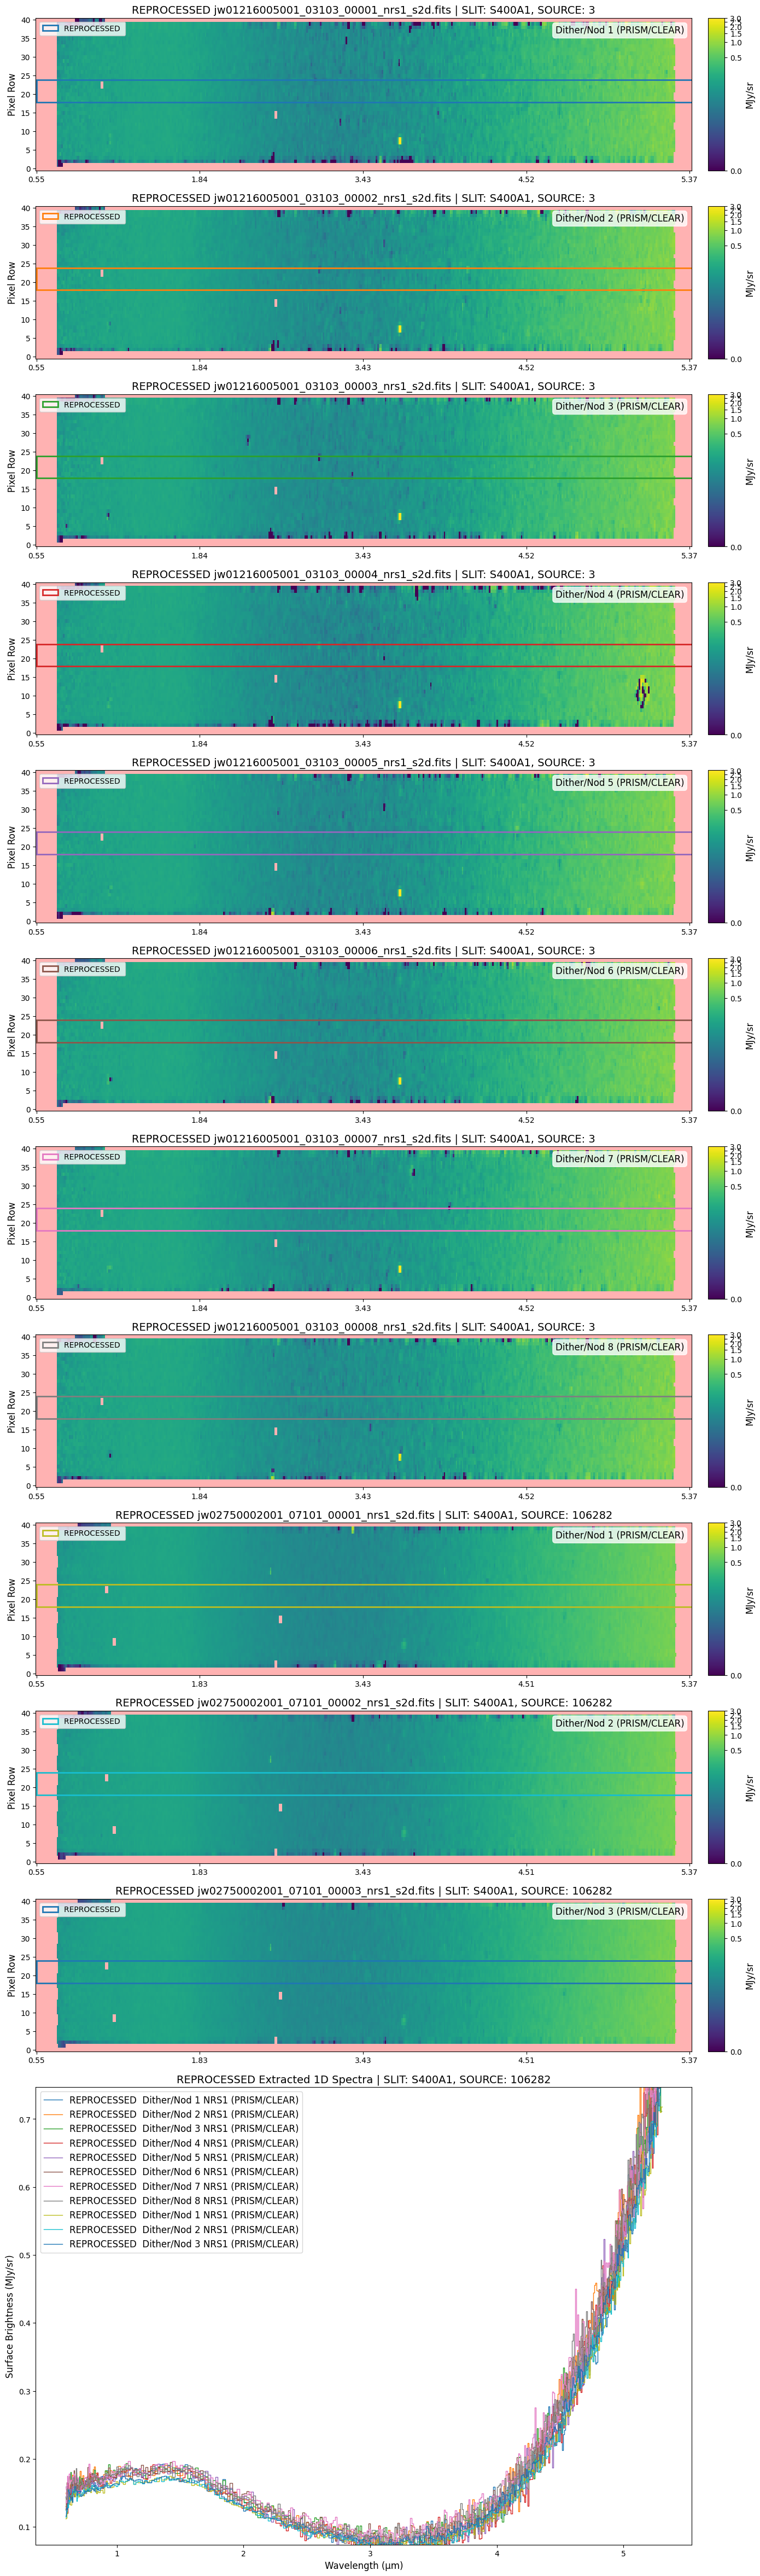

In [13]:
# Source units can be FLUX or SURF_BRIGHT.
display_spectra(sci_s2d + sci_x1d,
                source_id='S400A1', source_unit='SURF_BRIGHT', scale='log',
                vmin=0, vmax=3, #y_limits=(-1e-6, 0.3e-5),
                title_prefix='REPROCESSED', is_stage3=False)

---

## 7. Extract FS Data from MOS/IFU Observations (Stage 3)

Run Stage 3 and extract the spectra. We create Stage 3 association files here to show what a final stage 3 FS products look like.

In [14]:
# Set up a dictionary to define how the Spec3 pipeline should be configured.
spec3dict = defaultdict(dict)
spec3dict['extract_1d']['use_source_posn'] = True

In [15]:
# Write ASN files and proccess through Stage 3.
writel3asn(sci_cal, dir=stage2_dir)
for spec3_asn in glob.glob(stage2_dir+'*l3asn.json'):
        print(f"Applying Stage 3 Corrections & Calibrations to: "f"{os.path.basename(spec3_asn)}")
        spec3_result = Spec3Pipeline.call(spec3_asn,
                                          save_results=True,
                                          steps=spec3dict,
                                          output_dir=stage3_dir)
print("Stage 3 has been completed! \n")

Level 3 ASN creation complete!
Applying Stage 3 Corrections & Calibrations to: program02750_002_clear_prism_l3asn.json


2026-05-12 21:07:01,736 - CRDS - INFO -  Fetching  /home/runner/crds_cache/references/jwst/nirspec/jwst_nirspec_pars-outlierdetectionstep_0006.asdf    1.6 K bytes  (1 / 1 files) (0 / 1.6 K bytes)


2026-05-12 21:07:01,797 - stpipe.step - INFO - PARS-OUTLIERDETECTIONSTEP parameters found: /home/runner/crds_cache/references/jwst/nirspec/jwst_nirspec_pars-outlierdetectionstep_0006.asdf


2026-05-12 21:07:01,848 - stpipe.step - INFO - PARS-RESAMPLESPECSTEP parameters found: /home/runner/crds_cache/references/jwst/nirspec/jwst_nirspec_pars-resamplespecstep_0001.asdf


2026-05-12 21:07:01,942 - stpipe.step - INFO - Spec3Pipeline instance created.


...

2026-05-12 21:08:22,798 - stpipe.step - INFO - Step extract_1d done


2026-05-12 21:08:22,801 - jwst.pipeline.calwebb_spec3 - INFO - Ending calwebb_spec3


2026-05-12 21:08:22,814 - stpipe.step - INFO - Step Spec3Pipeline done


2026-05-12 21:08:22,815 - jwst.stpipe.core - INFO - Results used jwst version: 2.0.1


Stage 3 has been completed! 



In [16]:
# List the Stage 3 products.

stage3_cal = sorted(glob.glob(stage3_dir + '*_cal.fits'))
stage3_s2d = sorted(glob.glob(stage3_dir + '*_s2d.fits'))
stage3_x1d = sorted(glob.glob(stage3_dir + '*_x1d.fits'))

print(f"Stage 3 CAL Products:\n{'-' * 20}\n" + "\n".join(stage3_cal))
print(f"Stage 3 S3D Products:\n{'-' * 20}\n" + "\n".join(stage3_s2d))
print(f"Stage 3 X1D Products:\n{'-' * 20}\n" + "\n".join(stage3_x1d))

Stage 3 CAL Products:
--------------------
data/stage3/program01216_005_clear_prism_s1600a1_s000000004_cal.fits
data/stage3/program01216_005_clear_prism_s200a1_s000000001_cal.fits
data/stage3/program01216_005_clear_prism_s200a2_s000000002_cal.fits
data/stage3/program01216_005_clear_prism_s400a1_s000000003_cal.fits
data/stage3/program02750_002_clear_prism_s000106280_cal.fits
data/stage3/program02750_002_clear_prism_s000106281_cal.fits
data/stage3/program02750_002_clear_prism_s000106282_cal.fits
data/stage3/program02750_002_clear_prism_s000106283_cal.fits
Stage 3 S3D Products:
--------------------
data/stage3/program01216_005_clear_prism_s1600a1_s000000004_s2d.fits
data/stage3/program01216_005_clear_prism_s200a1_s000000001_s2d.fits
data/stage3/program01216_005_clear_prism_s200a2_s000000002_s2d.fits
data/stage3/program01216_005_clear_prism_s400a1_s000000003_s2d.fits
data/stage3/program02750_002_clear_prism_s000106280_s2d.fits
data/stage3/program02750_002_clear_prism_s000106281_s2d.fits
da

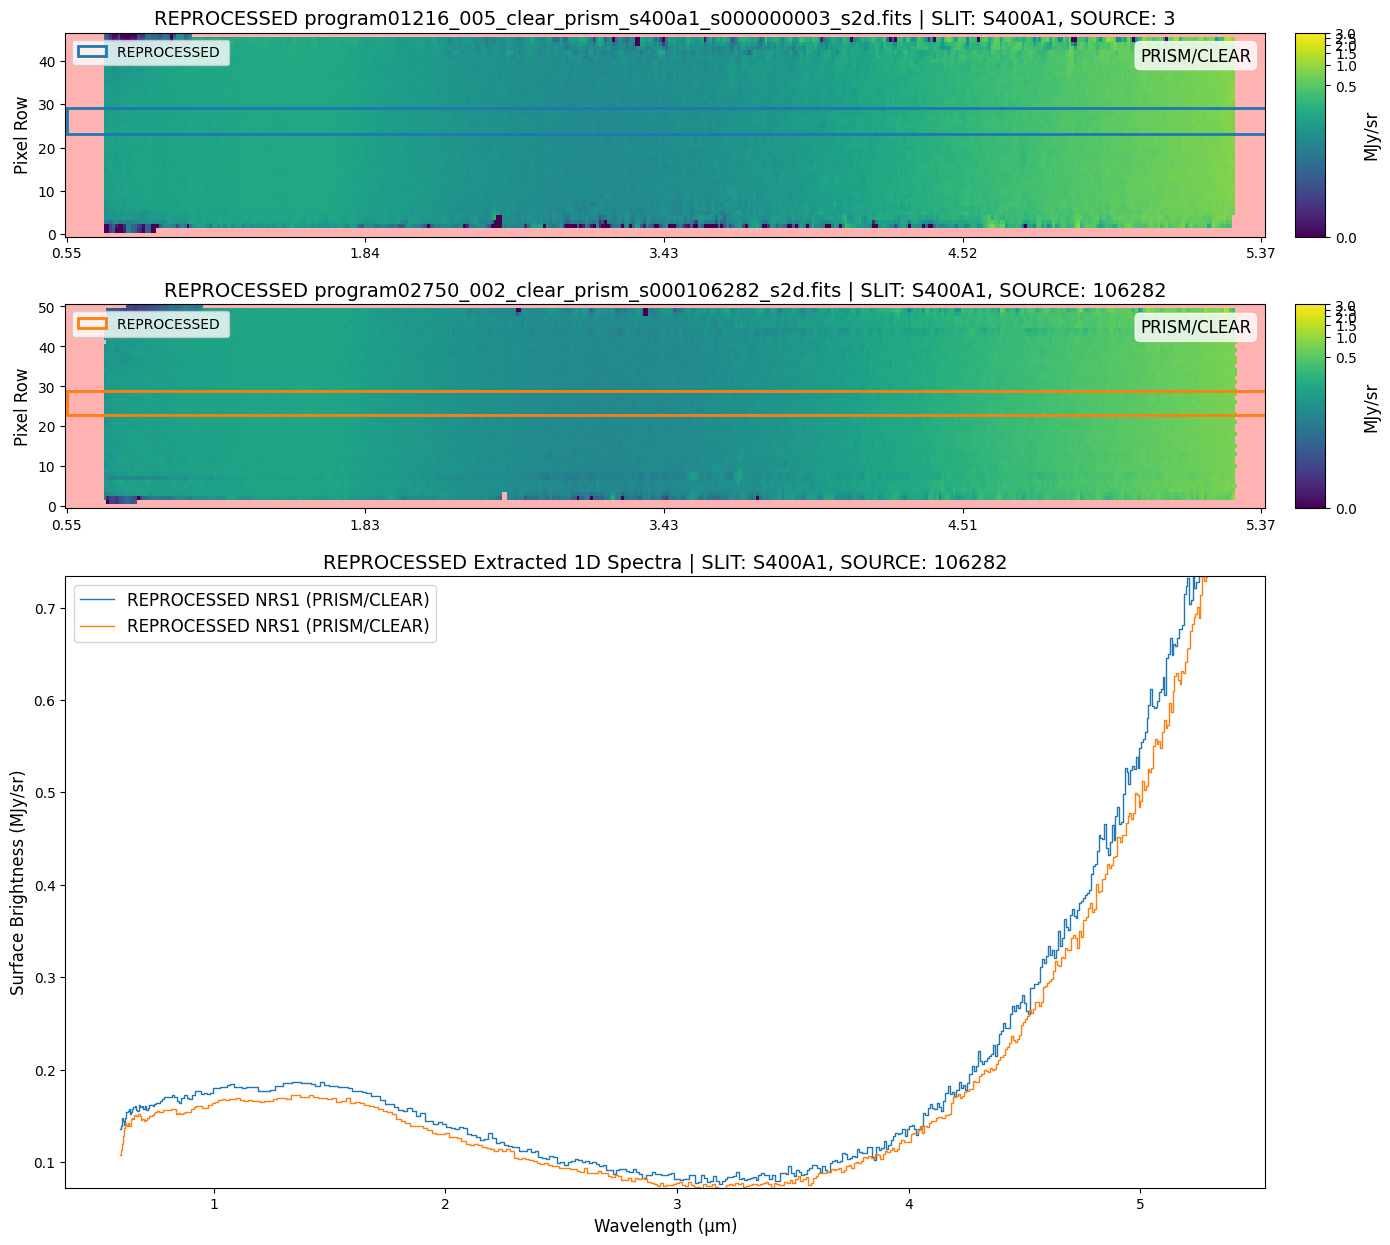

In [17]:
# Source units can be FLUX or SURF_BRIGHT.
display_spectra(stage3_s2d + stage3_x1d,
                source_id='S400A1', source_unit='SURF_BRIGHT', scale='log',
                vmin=0, vmax=3, #y_limits=(-1e-6, 0.3e-5),
                title_prefix='REPROCESSED', is_stage3=True)

If these final Stage 3 products are background, these can later be used in master background subtraction. For information on how to define different 1D extraction regions, refer to the notebooks listed below.

---
## Related Notebooks


* [NIRSpec MOS MSA Metafile](https://github.com/spacetelescope/jdat_notebooks/blob/main/notebooks/NIRSpec/msa_metafile/NIRSpec_MOS_MSA_metafile.ipynb)
* [NIRSpec Pipeline Notebooks](https://github.com/spacetelescope/jwst-pipeline-notebooks/tree/main/notebooks/NIRSPEC)

---

<figure>
       <img src="https://github.com/spacetelescope/jwst-pipeline-notebooks/blob/main/_static/stsci_footer.png?raw=true" alt="Space Telescope Logo\" align="right" style="width: 200px"/>
</figure>
   
[Top of Page](#Extracting-FS-Data-from-MOS/IFU-Observations)